# Exercise 1 — K-Means Clustering on Old Faithful Geyser Data

### Objective
Implement K-Means clustering on the Old Faithful geyser dataset and segregate the observations using:
- **`eruptions`** — duration of the eruption in minutes
- **`waiting`** — waiting time until the next eruption in minutes

This notebook uses **K = 2**, matching the version of this exercise that describes the 272-observation, 2-feature Old Faithful dataset.

**Dataset upload:** The notebook uses `files.upload()` so it works directly in Google Colab.

In [1]:
# Import the required libraries
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Upload the CSV file

we run this cell and select our `faithful.csv` file from computer.

In [2]:
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Uploaded file: {filename}')
print(f'Dataset shape: {df.shape}')
display(df.head())

Saving faithful.csv to faithful.csv
Uploaded file: faithful.csv
Dataset shape: (272, 3)


,Unnamed: 0,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


## 2. Check and prepare the dataset

The required variables are `eruptions` and `waiting`. Some downloaded CSV files contain an extra unnamed index column, so it is removed automatically if present.

In [3]:
# Remove accidental CSV index columns, if present
unnamed_cols = [col for col in df.columns if str(col).lower().startswith('unnamed')]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Check that the required columns exist
required_columns = ['eruptions', 'waiting']
missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f'Missing required column(s): {missing}. Found columns: {list(df.columns)}')

# Keep only the two features required by the exercise
data = df[required_columns].copy()

# Convert to numeric and remove missing rows, if any
data['eruptions'] = pd.to_numeric(data['eruptions'], errors='coerce')
data['waiting'] = pd.to_numeric(data['waiting'], errors='coerce')
data = data.dropna().reset_index(drop=True)

print('Final data shape:', data.shape)
print('\nMissing values:')
print(data.isnull().sum())
display(data.describe())

Final data shape: (272, 2)

Missing values:
eruptions    0
waiting      0
dtype: int64


,eruptions,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


## 3. Visualize the original data

Before clustering, we can inspect the relationship between eruption duration and waiting time.

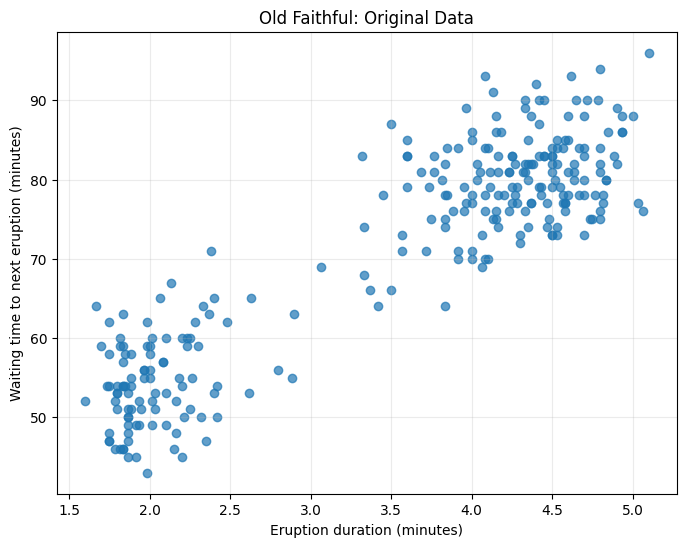

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(data['eruptions'], data['waiting'], alpha=0.7)
plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time to next eruption (minutes)')
plt.title('Old Faithful: Original Data')
plt.grid(alpha=0.25)
plt.show()

## 4. Standardize the two features

The exercise version uses standardization before K-Means. This puts `eruptions` and `waiting` on comparable scales.

In [5]:
X = data[['eruptions', 'waiting']].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print('Standardized feature matrix shape:', X_std.shape)
print('\nFirst 5 standardized observations:')
display(pd.DataFrame(X_std, columns=['eruptions_std', 'waiting_std']).head())

Standardized feature matrix shape: (272, 2)

First 5 standardized observations:


,eruptions_std,waiting_std
0,0.098499,0.597123
1,-1.481459,-1.245181
2,-0.135861,0.228663
3,-1.057503,-0.655644
4,0.917443,1.039277


## 5. Apply K-Means clustering (K = 2)

K-Means assigns each observation to one of two clusters and calculates the centroid (mean position) of each cluster.

In [6]:
k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_std)

data['Cluster'] = labels + 1  # Display clusters as 1 and 2

print('K-Means completed successfully.')
print('\nCluster counts:')
print(data['Cluster'].value_counts().sort_index())

print('\nInertia (within-cluster sum of squares):', round(kmeans.inertia_, 4))
print('Silhouette score:', round(silhouette_score(X_std, labels), 4))

K-Means completed successfully.

Cluster counts:
Cluster
1    174
2     98
Name: count, dtype: int64

Inertia (within-cluster sum of squares): 79.576
Silhouette score: 0.7452


## 6. Find the cluster centroids

K-Means calculates centroids in standardized space. The next cell converts them back to the original `eruptions` and `waiting` units so the result is easier to interpret.

In [7]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(
    centroids_original,
    columns=['eruptions', 'waiting'],
    index=['Cluster 1', 'Cluster 2']
)

print('Cluster centroids in original units:')
display(centroid_df.round(3))

Cluster centroids in original units:


,eruptions,waiting
Cluster 1,4.296,80.080
Cluster 2,2.052,54.592


## 7. Visualize the final clusters

This is the main result of the exercise: the observations are segregated into two groups according to eruption duration and waiting time.

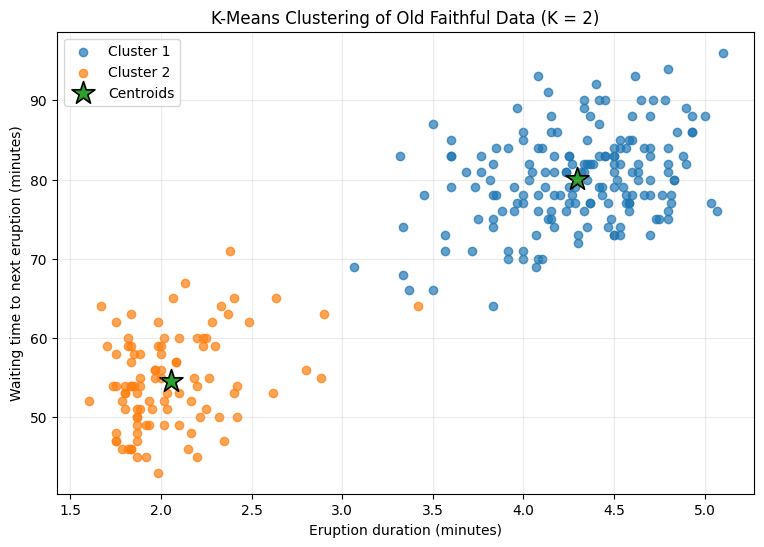

In [8]:
plt.figure(figsize=(9, 6))

for cluster_id in [1, 2]:
    subset = data[data['Cluster'] == cluster_id]
    plt.scatter(
        subset['eruptions'],
        subset['waiting'],
        alpha=0.7,
        label=f'Cluster {cluster_id}'
    )

plt.scatter(
    centroid_df['eruptions'],
    centroid_df['waiting'],
    marker='*',
    s=300,
    edgecolors='black',
    linewidths=1.2,
    label='Centroids'
)

plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time to next eruption (minutes)')
plt.title('K-Means Clustering of Old Faithful Data (K = 2)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 8. Optional: Elbow method for a smoother analysis

This is an additional analysis, not a replacement for the required K = 2 clustering. It shows how the within-cluster sum of squares (inertia) changes as K increases.

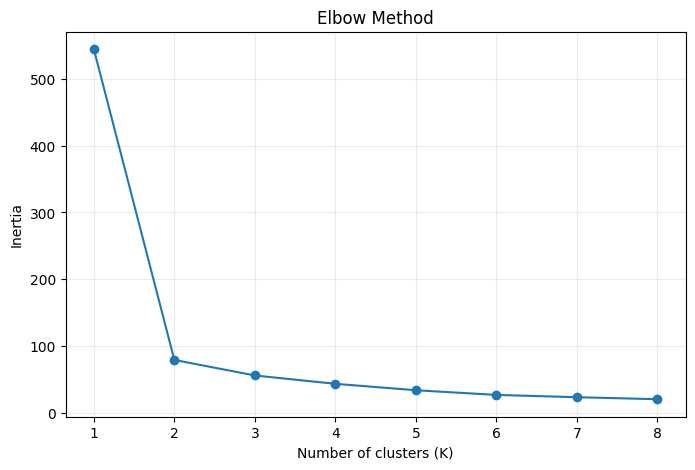

In [9]:
k_values = range(1, 9)
inertias = []

for k_test in k_values:
    model = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    model.fit(X_std)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_values))
plt.grid(alpha=0.25)
plt.show()

## 9. Optional: Compare silhouette scores

The silhouette score gives another way to inspect cluster separation. The required result remains the K = 2 model.

,K,Silhouette Score
0,2,0.7452
1,3,0.4851
2,4,0.3822
3,5,0.3628
4,6,0.3920
5,7,0.3915
6,8,0.3584


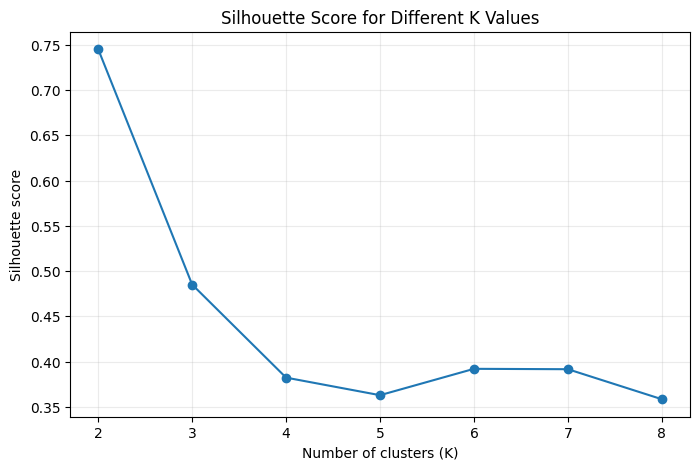

In [10]:
silhouette_results = []

for k_test in range(2, 9):
    model = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    test_labels = model.fit_predict(X_std)
    score = silhouette_score(X_std, test_labels)
    silhouette_results.append((k_test, score))

silhouette_df = pd.DataFrame(silhouette_results, columns=['K', 'Silhouette Score'])
display(silhouette_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(silhouette_df['K'], silhouette_df['Silhouette Score'], marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 9))
plt.grid(alpha=0.25)
plt.show()

## 10. Final cluster summary

The table below summarizes the average eruption duration and waiting time for each cluster in the original units.

In [11]:
summary = (
    data.groupby('Cluster')[['eruptions', 'waiting']]
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .round(3)
)

display(summary)

print('Conclusion:')
print('K-Means has segregated the Old Faithful observations into two clusters based on eruption duration and waiting time.')
print('The centroids above represent the typical eruption duration and waiting time for each cluster.')

eruptions                             waiting                       
            count   mean    std    min    max   count    mean    std min max
Cluster                                                                     
1             174  4.296  0.407  3.067  5.100     174  80.080  5.887  64  96
2              98  2.052  0.300  1.600  3.417      98  54.592  5.889  43  71

Conclusion:
K-Means has segregated the Old Faithful observations into two clusters based on eruption duration and waiting time.
The centroids above represent the typical eruption duration and waiting time for each cluster.
